In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv('tanks_data.csv')

y = data['Type']
X = data.drop(columns=['Type'])

n_features = X.shape[1]
n_rows = (n_features // 2) + (n_features % 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(12, n_rows * 4))
axes = axes.ravel()

colors = {
    'Artillery': 'blue',
    'Heavy Tank': 'orange',
    'Light Tank': 'green',
    'Medium Tank': 'red',
    'Tank Destroyer': 'purple'
}

for i in range(n_features):
    _, bins = np.histogram(X.iloc[:, i], bins=50)
    
    for tank_type, color in colors.items():
        subset = X[y == tank_type].iloc[:, i]
        axes[i].hist(subset, bins=bins, color=color, alpha=0.5, label=tank_type)
    
    axes[i].set_title(X.columns[i])
    axes[i].set_yticks(())

axes[0].set_xlabel("Значение признака")
axes[0].set_ylabel("Частота")
axes[0].legend(colors.keys(), loc="best")

fig.tight_layout()
plt.show()


In [ ]:
import pandas as pd
data = pd.read_csv('tanks_data.csv').drop(columns=['Type'])
corr = data.corr()
corr.style.background_gradient(cmap='coolwarm')

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

data = pd.read_csv('tanks_data.csv')

X = data.drop(columns=['Type'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

k = 2
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[22  1  0  0  0]
 [ 0 52  1  4  0]
 [ 0  0 28 16  1]
 [ 0  4  7 62  1]
 [ 0  4  0  6 41]]
                precision    recall  f1-score   support

     Artillery       1.00      0.96      0.98        23
    Heavy Tank       0.85      0.91      0.88        57
    Light Tank       0.78      0.62      0.69        45
   Medium Tank       0.70      0.84      0.77        74
Tank Destroyer       0.95      0.80      0.87        51

      accuracy                           0.82       250
     macro avg       0.86      0.83      0.84       250
  weighted avg       0.83      0.82      0.82       250



In [4]:
import pandas as pd
from KNN import ClassifierKNN 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

data = pd.read_csv('tanks_data.csv')

X = data.drop(columns=['Type'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = ClassifierKNN(metric='minkowski_1', n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

lowess_weights = model.lowess(kernel='gaussian')

#print("Lowess weights:", lowess_weights)


model_with_lowess = ClassifierKNN(metric='minkowski_1', n_neighbors=5, weights=lowess_weights)
model_with_lowess.fit(X_train, y_train)

y_pred_weighted = model_with_lowess.predict(X_test)
print(confusion_matrix(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))

[[20  0  0  0  0]
 [ 0 66  0  1  0]
 [ 0  0 43  0  0]
 [ 0  2  2 70  3]
 [ 0  0  0  1 42]]
                precision    recall  f1-score   support

     Artillery       1.00      1.00      1.00        20
    Heavy Tank       0.97      0.99      0.98        67
    Light Tank       0.96      1.00      0.98        43
   Medium Tank       0.97      0.91      0.94        77
Tank Destroyer       0.93      0.98      0.95        43

      accuracy                           0.96       250
     macro avg       0.97      0.97      0.97       250
  weighted avg       0.96      0.96      0.96       250

[[20  0  0  0  0]
 [ 0 66  0  1  0]
 [ 0  0 42  1  0]
 [ 0  2  4 68  3]
 [ 0  1  0  2 40]]
                precision    recall  f1-score   support

     Artillery       1.00      1.00      1.00        20
    Heavy Tank       0.96      0.99      0.97        67
    Light Tank       0.91      0.98      0.94        43
   Medium Tank       0.94      0.88      0.91        77
Tank Destroyer       0.93     

In [6]:
import KNN as knn
import pandas as pd
import numpy as np
import multiprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

data = pd.read_csv('tanks_data.csv')

X = data.drop(columns=['Type'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

param_dist = {
    'n_neighbors': randint(1, 10),
    'metric': ['euclidean', 'cosine', 'minkowski_2', 'minkowski_1', 'minkowski_3'],
    'kernel': ['general', 'uniform', 'gaussian', 'epanechnikov'],
    'a': np.linspace(0.01, 10, num=50),
    'b': np.linspace(0.01, 10, num=50)
}

knn_model = knn.ClassifierKNN()
n_jobs = multiprocessing.cpu_count() - 1

random_search = RandomizedSearchCV(knn_model, param_dist, cv=5, n_iter=100, n_jobs=n_jobs)
random_search.fit(X_train, y_train)

print("Лучшие параметры:", random_search.best_params_)
print("Лучшая точность:", random_search.best_score_)

#Лучшие параметры: {'a': 1, 'b': 2, 'kernel': 'gaussian', 'metric': 'minkowski_1', 'n_neighbors': 5, 'window_size': 15}
#Лучшая точность: 0.9383534675615213


Лучшие параметры: {'a': np.float64(1.437142857142857), 'b': np.float64(0.21387755102040817), 'kernel': 'gaussian', 'metric': 'minkowski_1', 'n_neighbors': 8}
Лучшая точность: 0.925020134228188


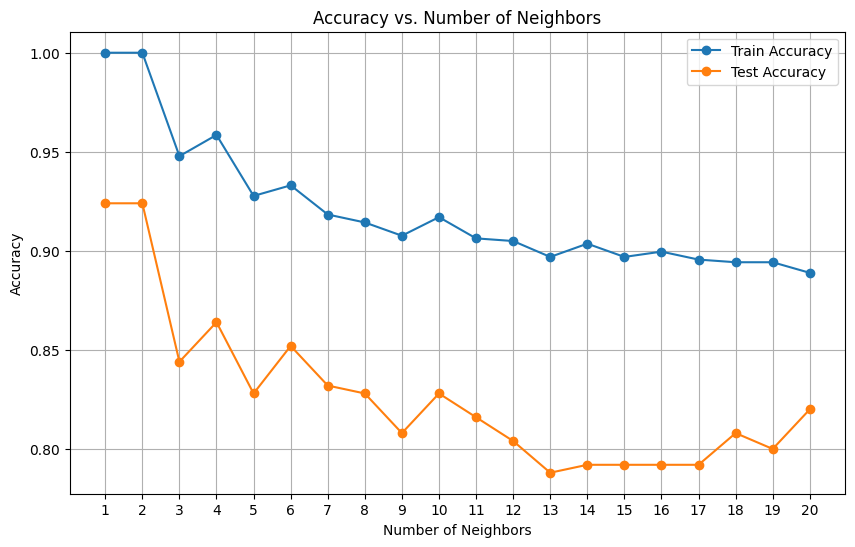

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from KNN import ClassifierKNN

data = pd.read_csv('tanks_data.csv')
X = data.drop(columns=['Type'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

metric = 'minkowski_2'
kernel = 'gaussian'

neighbors_range = range(1, 21)

train_scores = []
test_scores = []

for n_neighbors in neighbors_range:
    model = ClassifierKNN(n_neighbors=n_neighbors, metric=metric, 
                          kernel=kernel)
    
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_pred)
    train_scores.append(train_accuracy)

    test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_pred)
    test_scores.append(test_accuracy)

plt.figure(figsize=(10, 6))
plt.plot(neighbors_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(neighbors_range, test_scores, label='Test Accuracy', marker='o')
plt.title('Accuracy vs. Number of Neighbors')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.xticks(neighbors_range)
plt.grid()
plt.legend()
plt.show()
